In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Non-supervised Learning
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

# Supervised Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Warning
import warnings
warnings.filterwarnings('ignore')

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
ruta_proyecto = "../02_datos/03_Entrenamiento/"

ruta_x = ruta_proyecto + '06_x_preseleccionado.pkl'
ruta_y = ruta_proyecto + '06_y_preseleccionado.pkl'

try:
    x = pd.read_pickle(ruta_x)
    y = pd.read_pickle(ruta_y)

    # Avisamos al usuario
    print(f"✅ Dataframe {ruta_x} y {ruta_y} exportado correctamente")

except:
    print(f"❌ Dataframe {ruta_x} y {ruta_y} NO se han exportado")

✅ Dataframe ../02_datos/03_Entrenamiento/06_x_preseleccionado.pkl y ../02_datos/03_Entrenamiento/06_y_preseleccionado.pkl exportado correctamente


## 0. Separamos entrenamiento y validacion

In [3]:
train_x, val_x, train_y, val_y= train_test_split(x, y, test_size=0.3)

# 1. Modelización

El objetivo de este proyecto es un proyecto de Clasificación, ya que queremos predecir si un Lead va a convertir o no.

## 1.1. Instanciamos los modelos

In [4]:
pipe = Pipeline([('algoritmo', RandomForestClassifier())])

grid = [{'algoritmo': [LogisticRegression()],
          'algoritmo__n_jobs': [-1],
          'algoritmo__solver': ['saga'],
          'algoritmo__penalty': ['elasticnet', 'l1', 'l2', 'none'],
          'algoritmo__C': [0, 0.25, 0.5, 0.75, 1]},
        ]

## 1.2. Optimizamos hiper-parámetros

Existen dos opciones: Grid Search y Random Search, en este caso, como vamos a entrenar el algoritmo de Linear Regression, vamos a usar **Grid Search**. 

### Grid Search

In [5]:
grid_search = GridSearchCV(estimator=pipe,
                           param_grid=grid,
                           cv = 3,
                           scoring= 'roc_auc',
                           verbose=0,
                           n_jobs=-1
                           )

modelo = grid_search.fit(train_x, train_y)

pd.DataFrame(grid_search.cv_results_).sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__n_jobs,param_algoritmo__penalty,param_algoritmo__solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
17,0.009,0.001,0.001,0.000,LogisticRegression(),1.000,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.850,0.859,0.877,0.862,0.011,1
13,0.010,0.002,0.002,0.000,LogisticRegression(),0.750,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.850,0.859,0.877,0.862,0.011,2
9,0.013,0.004,0.002,0.000,LogisticRegression(),0.500,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.850,0.859,0.876,0.862,0.011,3
18,0.010,0.002,0.001,0.000,LogisticRegression(),1.000,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.848,0.859,0.875,0.860,0.011,4
16,0.011,0.003,0.002,0.001,LogisticRegression(),1.000,-1,elasticnet,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.848,0.859,0.875,0.860,0.011,5
14,0.008,0.002,0.002,0.001,LogisticRegression(),0.750,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.847,0.858,0.874,0.860,0.011,6
12,0.008,0.001,0.002,0.000,LogisticRegression(),0.750,-1,elasticnet,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.847,0.858,0.874,0.860,0.011,7
5,0.012,0.004,0.003,0.001,LogisticRegression(),0.250,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.847,0.857,0.874,0.859,0.011,8
10,0.007,0.002,0.002,0.000,LogisticRegression(),0.500,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.844,0.856,0.872,0.858,0.011,9
8,0.007,0.002,0.002,0.000,LogisticRegression(),0.500,-1,elasticnet,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.844,0.856,0.872,0.858,0.011,10


## 1.3. Evaluamos el modelo

### Predecir sobre validación

In [6]:
pred = modelo.best_estimator_.predict_proba(val_x)[:,1]
pred

array([0.12921532, 0.86750133, 0.83528347, ..., 0.21836048, 0.05278308,
       0.97104393], shape=(1452,))

### Evaluar sobre validación

In [7]:
roc_auc_score(val_y, pred)

0.8654058052987883

Predice **acertando entorno en un 86% de predicción, por lo tanto, se trata de una predicción muy alta**.

### Examinamos el mejor modelo

In [8]:
# Para extraer solo los valores a seleccionar sin valores por defecto
# modelo.best_params_

modelo.best_estimator_.get_params()

{'memory': None,
 'steps': [('algoritmo',
   LogisticRegression(C=1, n_jobs=-1, penalty='l1', solver='saga'))],
 'transform_input': None,
 'verbose': False,
 'algoritmo': LogisticRegression(C=1, n_jobs=-1, penalty='l1', solver='saga'),
 'algoritmo__C': 1,
 'algoritmo__class_weight': None,
 'algoritmo__dual': False,
 'algoritmo__fit_intercept': True,
 'algoritmo__intercept_scaling': 1,
 'algoritmo__l1_ratio': 0.0,
 'algoritmo__max_iter': 100,
 'algoritmo__n_jobs': -1,
 'algoritmo__penalty': 'l1',
 'algoritmo__random_state': None,
 'algoritmo__solver': 'saga',
 'algoritmo__tol': 0.0001,
 'algoritmo__verbose': 0,
 'algoritmo__warm_start': False}

In [9]:
modelo.best_params_

{'algoritmo': LogisticRegression(),
 'algoritmo__C': 1,
 'algoritmo__n_jobs': -1,
 'algoritmo__penalty': 'l1',
 'algoritmo__solver': 'saga'}

# 2. Reporting del Modelo

## 2.1. Gain Chart

In [11]:
# Parche para scikitplot con scipy reciente
import scipy.interpolate as interpolate
import sys
sys.modules['scipy.interp'] = interpolate

import scikitplot as skplt

TypeError: 'ArtistList' object doesn't support item deletion

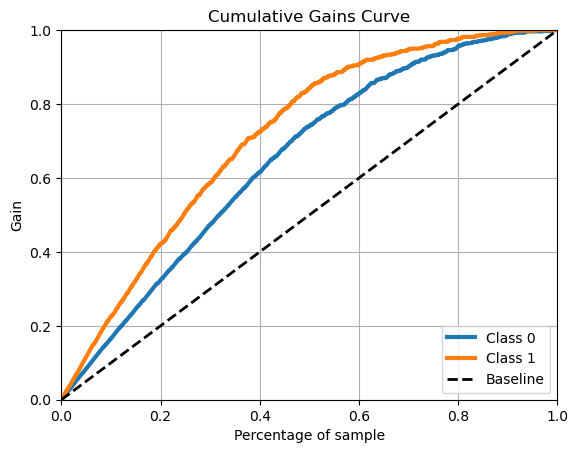

In [17]:
fig, ax = plt.subplots()
skplt.metrics.plot_cumulative_gain(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax)

# Personalizamos la leyenda
del ax.lines[0]
plt.legend(labels = ['Modelo', 'Aleatoria'])

Para futuras versiones de estos gráficos es recomendable usar un código que no dependa de `scikit-plot` como sería:

In [22]:
# Descomentar: cmd + lift + /

# y_probas = modelo.best_estimator_.predict_proba(val_x)
# # Asumimos clase positiva = 1 (ajusta si es distinto)
# pos_idx = list(modelo.best_estimator_.classes_).index(1)
# proba_pos = y_probas[:, pos_idx]

# # Ordenar por probabilidad descendente
# order = np.argsort(proba_pos)[::-1]
# y_sorted = np.array(val_y)[order]

# n = len(y_sorted)
# total_pos = y_sorted.sum()
# pct_population = np.arange(1, n + 1) / n


# # ── CUMULATIVE GAIN ──────────────────────────────────────────
# cumulative_pos = np.cumsum(y_sorted)
# gain = cumulative_pos / total_pos

# fig, ax = plt.subplots()
# ax.plot(pct_population, gain, label='Modelo')
# ax.plot([0, 1], [0, 1], 'k--', label='Aleatoria')
# ax.set_xlabel('Porcentaje de población contactada')
# ax.set_ylabel('Porcentaje de positivos capturados')
# ax.set_title('Cumulative Gain')
# ax.legend()
# plt.show()

## 2.2. Lift Chart

TypeError: 'ArtistList' object doesn't support item deletion

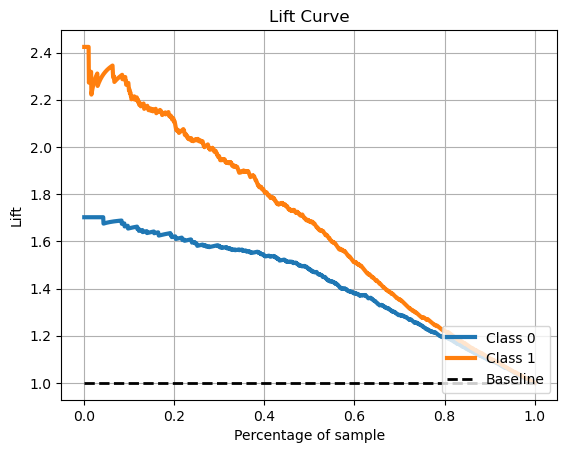

In [19]:
fig, ax = plt.subplots()
skplt.metrics.plot_lift_curve(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax)

# Eliminamos línea de 0 y modificamos leyenda
del ax.lines[0]
plt.legend(labels = ['Modelo', 'Aleatoria'])

## 2.3. ROC Chart

Esta la vamos a construir directamente sin usar `skplt`ya que `scikit-plot` no tiene mantenimiento activo y no se ha actualizado a numpy 2.0 tras la modificación.

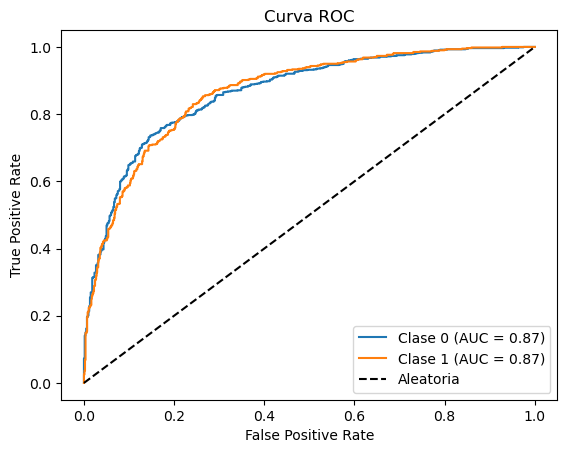

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

y_probas = modelo.best_estimator_.predict_proba(val_x)
classes = modelo.best_estimator_.classes_

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(val_y, y_probas[:, i], pos_label=cls)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'Clase {cls} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Aleatoria')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC')
ax.legend()
plt.show()

## 2.4. Report de mejores variables

Accedemos a aquellas variables con mejor capacidad predictiva, al estar en la misma escala, podemos usar los coeficientes para comparar entre sí. 

In [41]:
pd.DataFrame(data= modelo.best_estimator_.named_steps.algoritmo.coef_,
             columns =modelo.best_estimator_.named_steps.algoritmo.feature_names_in_).unstack() \
.sort_values(ascending=False)

score_actividad_mms                    0    8.707
tiempo_en_site_total_mms               0    4.075
ocupacion_Working Professional         0    1.618
score_perfil_mms                       0    1.562
ult_actividad_SMS Sent                 0    1.060
descarga_lm_No                         0    0.749
visitas_total_mms                      0    0.000
ambito_Select                          0   -0.554
ult_actividad_Page Visited on Website  0   -0.791
ocupacion_Unemployed                   0   -1.003
ult_actividad_Chat Conversation        0   -1.443
ult_actividad_Converted to Lead        0   -1.671
paginas_vistas_visita_mms              0   -2.748
dtype: float64

Nuestro modelo nos dice que las variables con mayor predicción son `tiempo_site_total_mms` > `score_actividad_mms` > `paginas_vistas_visita_mms`. Aunque esta última ocurre algo curioso, ya que nos indica que a menor número de páginas vistas, mayor conversión. Lo que puede ocurrir es debido a la correlación entre variables, ya que normalmente, lo que esta variable tiene por aportar ya lo ha aportado otra, de forma que, lo único que tiene por aportar es algo residual y de ahí el signo negativo.